In [53]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['SimHei']  # 配置可视化中文显示

In [9]:
# 数据清洗（重复，缺失，格式调整）
data = pd.read_csv('../data/data_wuliu.csv', encoding='gbk')
# 通过info函数可以看出有的列数据有缺失(订单号,货品交货状况,数量)，订单行删除，销售额列格式不对，需要调整转换
# 删除重复记录
data.drop_duplicates(keep='first', inplace=True)  # 遇到重复保留第一行，并修改数据
# 删除缺失值(有NA就删除整行)
data.dropna(axis=0, how='any', inplace=True)
# 删除订单行
data.drop(columns=['订单行'], inplace=True)
# 更新索引
data.reset_index(drop=True, inplace=True)


# 调整金额格式
def data_deal(number):
    if number.find('万元') != -1:
        number_new = float(number[:number.find('万元')].replace(',', '')) * 10000
    elif number.find('元') != -1:
        number_new = float(number.replace('元', '').replace(',', ''))
    else:
        number_new = number
    return number_new


data['销售金额'] = data['销售金额'].map(data_deal)

# 异常值处理
# 1.销售金额为0，数量为1直接删除掉
# 2.数量/销售金额标准值是均值的8倍之多，且二分之一分位数也为1，说明数据严重右偏(2/8法则)->属于正常现象无须处理
data = data[data['销售金额'] != 0]
# 月份预处理
data['销售时间'] = pd.to_datetime(data['销售时间'])
data['月份'] = data['销售时间'].apply(lambda x: x.month)

In [12]:
# 数据分析可视化
# 1.配送服务是否有异常

In [37]:
# 1.配送服务是否有异常
# 1.1.月份维度
data['货品交货状况'] = data['货品交货状况'].str.strip()  # 去除空格
data1 = data.groupby(['月份', '货品交货状况']).size().unstack()  # unstack：以列形式进行分组后显示
data1['按时交货率'] = round(data1['按时交货'] / (data1['按时交货'] + data1['晚交货']) * 100, 2)  # 看出交货率根据季节转变不断下降

货品交货状况,按时交货,晚交货,按时交货率
月份,,,
7,189,13,93.56
8,218,35,86.17
9,122,9,93.13
10,238,31,88.48
11,101,25,80.16
12,146,18,89.02


In [40]:
# 1.2.区域维度
data1 = data.groupby(['销售区域', '货品交货状况']).size().unstack()  # unstack：以列形式进行分组后显示
data1['按时交货率'] = round(data1['按时交货'] / (data1['按时交货'] + data1['晚交货']) * 100, 2)
print(data1.sort_values(by='按时交货率',ascending=False))

货品交货状况  按时交货  晚交货  按时交货率
销售区域                    
泰国       183    4  97.86
马来西亚     310   16  95.09
华南        10    1  90.91
华北       226   27  89.33
华东       268   39  87.30
西北        17   44  27.87


In [35]:
# 1.3.货品维度
data1 = data.groupby(['货品', '货品交货状况']).size().unstack()  # unstack：以列形式进行分组后显示
data1['按时交货率'] = round(data1['按时交货'] / (data1['按时交货'] + data1['晚交货']) * 100, 2)
print(data1.sort_values(by='按时交货率',ascending=False)) # 货品4晚交货情况严重

货品交货状况  按时交货  晚交货  按时交货率
货品                      
货品5      183    4  97.86
货品6      309    7  97.78
货品1       27    2  93.10
货品3      212   26  89.08
货品2      269   48  84.86
货品4       14   44  24.14


In [43]:
# 1.4.货品+销售区域维度
data1 = data.groupby(['货品', '销售区域', '货品交货状况']).size().unstack()  # unstack：以列形式进行分组后显示
data1['按时交货率'] = round(data1['按时交货'] / (data1['按时交货'] + data1['晚交货']) * 100, 2)
print(data1.sort_values(by='按时交货率', ascending=False))  # 销售区域西北最差，货品1和4，其中货品4送的较晚导致 货品角度货品2送往马来西亚最晚

货品交货状况     按时交货   晚交货  按时交货率
货品  销售区域                    
货品5 泰国    183.0   4.0  97.86
货品6 马来西亚  309.0   7.0  97.78
货品1 华北     14.0   1.0  93.33
    华南     10.0   1.0  90.91
货品3 华北    212.0  26.0  89.08
货品2 华东    268.0  39.0  87.30
货品4 西北     14.0  44.0  24.14
货品2 马来西亚    1.0   9.0  10.00
货品1 西北      3.0   NaN    NaN


<Axes: xlabel='月份'>

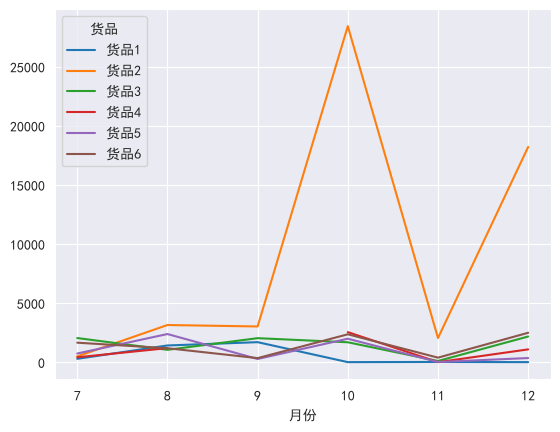

In [55]:
# 2.是否存在尚有潜力的销售区域
# 1.月份维度->货品2在10月和12月销量猛涨，1.公司加大营销力度，2.开发新市场导致(后续分析并不是，而是前者，增加的营销力度)
data1 = data.groupby(['月份','货品'])['数量'].sum().unstack()
data1.plot(kind='line')

<Axes: xlabel='销售区域'>

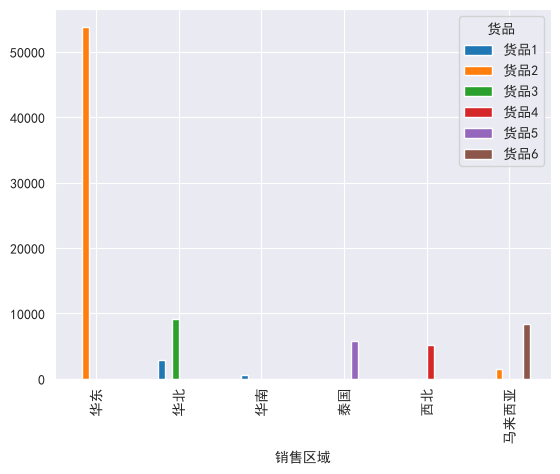

In [57]:
# 从销售区域看，每种货品有1~3个销售区域，货品1有3个销售区域，货品2有2个销售区域，其余只有1个销售区域
data1 = data.groupby(['销售区域','货品'])['数量'].sum().unstack()
data1.plot(kind='bar')

In [64]:
# 月份区域结合分析->在10，12月份销量猛增，主要发生在华东地区，且可以看出需要在其他月份加大营销力度！
data1 = data.groupby(['月份','销售区域','货品'])['数量'].sum().unstack()
data1['货品2']

月份  销售区域
7   华东        489.0
    华北          NaN
    华南          NaN
    泰国          NaN
    西北          NaN
    马来西亚        2.0
8   华东       1640.0
    华北          NaN
    华南          NaN
    泰国          NaN
    西北          NaN
    马来西亚     1503.0
9   华东       3019.0
    华北          NaN
    华南          NaN
    泰国          NaN
    西北          NaN
    马来西亚        1.0
10  华东      28420.0
    华北          NaN
    泰国          NaN
    西北          NaN
    马来西亚        NaN
11  华东       2041.0
    华北          NaN
    华南          NaN
    泰国          NaN
    西北          NaN
    马来西亚        1.0
12  华东      18202.0
    华北          NaN
    华南          NaN
    泰国          NaN
    西北          NaN
    马来西亚        3.0
Name: 货品2, dtype: float64